In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight


2026-01-16 05:39:38.953387: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768541979.191767      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768541979.251991      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768541979.785599      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768541979.785652      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768541979.785655      55 computation_placer.cc:177] computation placer alr

In [4]:
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')

data = train_transaction.merge(train_identity, how='left', on='TransactionID')



In [5]:
print(train_transaction.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

In [6]:
print(train_identity.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [7]:
y = data['isFraud']
X = data.drop(['isFraud', 'TransactionID'], axis=1)


In [8]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

# Handle missing values
X[cat_cols] = X[cat_cols].fillna('missing')
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Encode categorical variables
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# Scale numeric features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Reduce memory
X[num_cols] = X[num_cols].astype('float32')


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


In [11]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768542119.491087      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768542119.495028      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['AUC']
)


In [13]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=6,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30


I0000 00:00:1768542152.222098     185 service.cc:152] XLA service 0x7a4d54003590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768542152.222133     185 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768542152.222137     185 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768542152.766650     185 cuda_dnn.cc:529] Loaded cuDNN version 91002


 28/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.6221 - loss: 0.8050

I0000 00:00:1768542156.547686     185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - AUC: 0.7299 - loss: 0.6615 - val_AUC: 0.8190 - val_loss: 0.3731
Epoch 2/30
 19/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8149 - loss: 0.5382

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8173 - loss: 0.5295 - val_AUC: 0.8365 - val_loss: 0.5545
Epoch 3/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8302 - loss: 0.5092 - val_AUC: 0.8262 - val_loss: 0.8538
Epoch 4/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8448 - loss: 0.4898 - val_AUC: 0.8505 - val_loss: 0.3164
Epoch 5/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8500 - loss: 0.4771 - val_AUC: 0.8557 - val_loss: 0.5141
Epoch 6/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8559 - loss: 0.4704 - val_AUC: 0.8265 - val_loss: 0.3583
Epoch 7/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8569 - loss: 0.4665 - val_AUC: 0.8489 - val_loss: 0.6002
Epoch 8/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8598 - loss: 0.4639 - val_AUC: 0.8536 - val_loss: 0.2609
Epoch 9/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8633 - loss: 0.4566 - val_AUC: 0.8368 - val_loss: 0.7767
Epoch 10/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8647 

In [14]:
val_preds = model.predict(X_val).ravel()
auc = roc_auc_score(y_val, val_preds)
print("Validation AUC:", auc)


3691/3691 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Validation AUC: 0.8765060339882288


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

# Choose decision threshold
threshold = 0.5

y_pred = (val_preds >= threshold).astype(int)

cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Confusion Matrix:
[[61517 52458]
 [  359  3774]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.54      0.70    113975
           1       0.07      0.91      0.13      4133

    accuracy                           0.55    118108
   macro avg       0.53      0.73      0.41    118108
weighted avg       0.96      0.55      0.68    118108



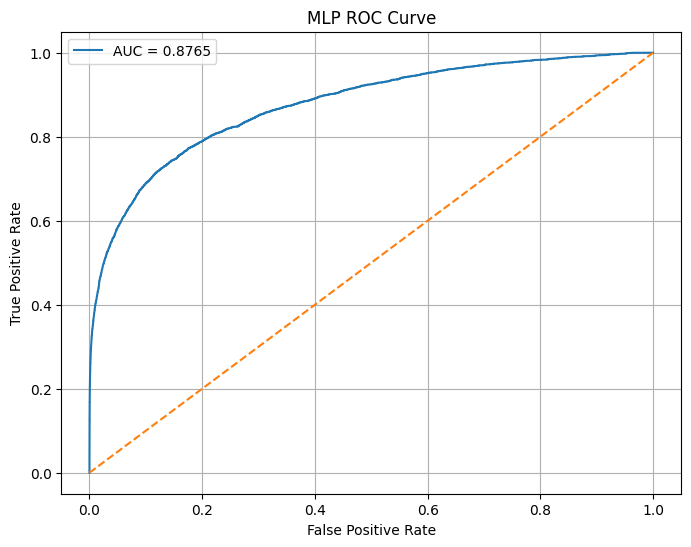

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, val_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP ROC Curve')
plt.legend()
plt.grid()
plt.show()
